## I. Audit tổng quan

In [1]:
import sys
import os

# Add the parent directory to the sys.path
sys.path.append(os.path.abspath('..'))

import pandas as pd
from src.utils import audit

df = pd.read_csv("../data/raw/ecommerce_customer_data_custom_ratios.csv")
audit(df).sort_values("pct_missing", ascending=False)


,dtype,n_missing,pct_missing,n_unique,sample
Returns,float64,47596,19.0,2,0.0
Purchase Date,str,0,0.0,249736,2020-09-08 09:38:32
Product Category,str,0,0.0,4,Electronics
Product Price,int64,0,0.0,491,12
Customer ID,int64,0,0.0,49673,46251
Quantity,int64,0,0.0,5,3
Total Purchase Amount,int64,0,0.0,5247,740
Payment Method,str,0,0.0,4,Credit Card
Customer Age,int64,0,0.0,53,37
Customer Name,str,0,0.0,39920,Christine Hernandez


In [3]:
for c in df.select_dtypes("str"):
    print(c, df[c].value_counts().head(10), sep="\n", end="\n\n")

Purchase Date
Purchase Date
2022-05-08 12:58:55    3
2022-03-05 14:57:06    2
2022-09-13 13:56:26    2
2022-05-19 16:04:11    2
2022-10-31 15:03:26    2
2022-05-01 11:15:56    2
2021-04-15 04:27:49    2
2021-09-23 15:26:59    2
2021-09-03 01:13:12    2
2021-11-24 13:23:14    2
Name: count, dtype: int64

Product Category
Product Category
Clothing       75052
Books          74912
Electronics    50185
Home           49851
Name: count, dtype: int64

Payment Method
Payment Method
Credit Card    100486
PayPal          74837
Cash            49894
Crypto          24783
Name: count, dtype: int64

Customer Name
Customer Name
Michael Smith        107
John Smith           103
Jennifer Smith       102
Michael Johnson       98
Lisa Smith            97
James Smith           95
Christopher Smith     83
Michael Brown         79
James Brown           76
Jennifer Williams     74
Name: count, dtype: int64

Gender
Gender
Female    125560
Male      124440
Name: count, dtype: int64



In [4]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [5]:
(df["Customer Age"] == df["Age"]).all()

np.True_

##                    ->  2 cột "Customer Age" và "Age" trùng nhau

In [6]:
df.Returns.value_counts(dropna=False)

df.groupby("Payment Method")["Returns"].apply(lambda s: s.isna().mean())

Payment Method
Cash           0.190163
Credit Card    0.189997
Crypto         0.192955
PayPal         0.190200
Name: Returns, dtype: float64

In [7]:
df.groupby("Product Category")["Returns"].apply(lambda s: s.isna().mean())

Product Category
Books          0.191118
Clothing       0.190841
Electronics    0.189858
Home           0.189124
Name: Returns, dtype: float64

In [8]:
df = df.drop(columns=["Customer Age"])

In [9]:
df.columns.tolist()

['Customer ID',
 'Purchase Date',
 'Product Category',
 'Product Price',
 'Quantity',
 'Total Purchase Amount',
 'Payment Method',
 'Returns',
 'Customer Name',
 'Age',
 'Gender',
 'Churn']

## II. Xử lý missing

In [10]:
df["Returns_was_missing"] = df["Returns"].isna().astype(int)
df["Returns"] = df["Returns"].fillna(0)

In [13]:
audit(df).sort_values("pct_missing", ascending=False)

,dtype,n_missing,pct_missing,n_unique,sample
Customer ID,int64,0,0.0,49673,46251
Purchase Date,str,0,0.0,249736,2020-09-08 09:38:32
Product Category,str,0,0.0,4,Electronics
Product Price,int64,0,0.0,491,12
Quantity,int64,0,0.0,5,3
Total Purchase Amount,int64,0,0.0,5247,740
Payment Method,str,0,0.0,4,Credit Card
Returns,float64,0,0.0,2,0.0
Customer Name,str,0,0.0,39920,Christine Hernandez
Age,int64,0,0.0,53,37


## III. Outlier

array([[<Axes: title={'center': 'Product Price'}>,
        <Axes: title={'center': 'Total Purchase Amount'}>],
       [<Axes: title={'center': 'Quantity'}>,
        <Axes: title={'center': 'Age'}>]], dtype=object)

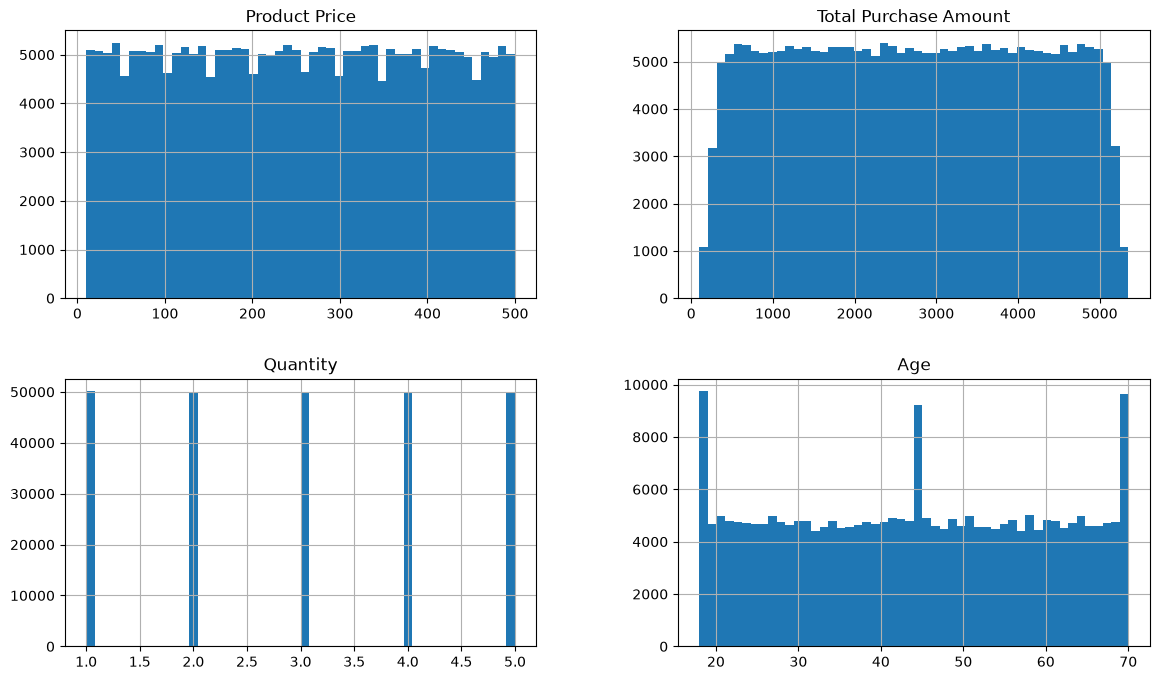

In [15]:
df[["Product Price", "Total Purchase Amount", "Quantity", "Age"]].hist(bins=50, figsize=(14,8))

In [16]:
df["Age"].value_counts().sort_values(ascending=False).head(10)

top_age = df["Age"].value_counts().idxmax()
df[df["Age"] == top_age].describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Returns,Age,Churn,Returns_was_missing
count,5009.000000,5009.000000,5009.000000,5009.000000,5009.000000,5009.0,5009.000000,5009.000000
mean,24710.364145,256.494710,3.015173,2780.423837,0.401677,58.0,0.208824,0.196047
std,14440.069151,142.151758,1.405208,1433.715320,0.490286,0.0,0.406509,0.397044
min,10.000000,10.000000,1.000000,304.000000,0.000000,58.0,0.000000,0.000000
25%,12170.000000,133.000000,2.000000,1551.000000,0.000000,58.0,0.000000,0.000000
50%,23939.000000,258.000000,3.000000,2760.000000,0.000000,58.0,0.000000,0.000000
75%,37522.000000,381.000000,4.000000,4022.000000,1.000000,58.0,0.000000,0.000000
max,49974.000000,500.000000,5.000000,5289.000000,1.000000,58.0,1.000000,1.000000


<Axes: >

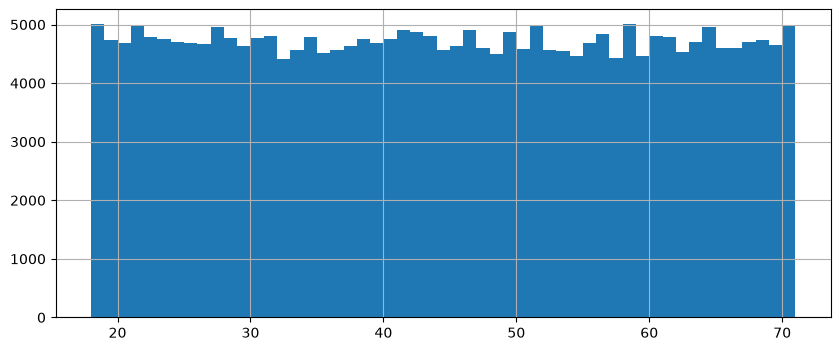

In [17]:
df["Age"].hist(bins=range(18, 72), figsize=(10,4))

<Axes: >

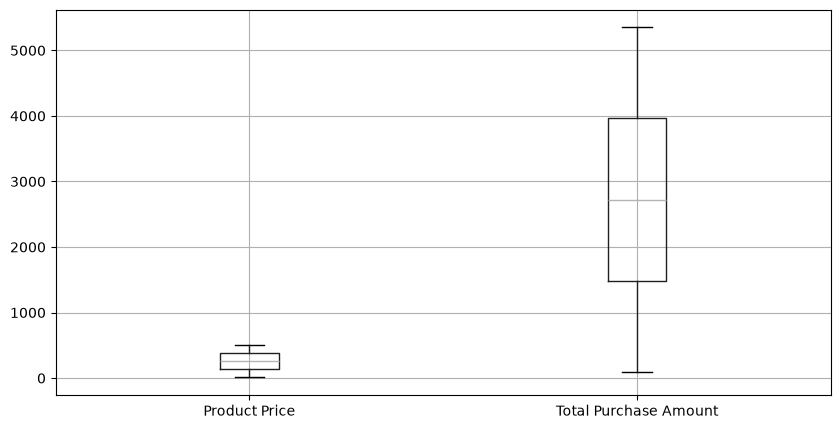

In [18]:
df.boxplot(column=["Product Price", "Total Purchase Amount"], figsize=(10,5))

In [20]:
import importlib
import src.utils
importlib.reload(src.utils)
from src.utils import modified_z_mask, iqr_mask

for col in ["Product Price", "Total Purchase Amount"]:
    mz = modified_z_mask(df[col])
    iq = iqr_mask(df[col])
    print(f"{col}: modified-Z flags {mz.sum()} ({mz.mean():.2%}), "
          f"IQR flags {iq.sum()} ({iq.mean():.2%})")

Product Price: modified-Z flags 0 (0.00%), IQR flags 0 (0.00%)
Total Purchase Amount: modified-Z flags 0 (0.00%), IQR flags 0 (0.00%)


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.duplicated(subset=["Customer ID", "Purchase Date", "Product Category"]).sum()

np.int64(0)

In [5]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Purchase Date"].dtype  

dtype('<M8[us]')

In [6]:
from src.utils import run_checks
checks = {
    "age trong khoảng hợp lý (18-100)": df["Age"].between(18, 100),
    "price > 0": df["Product Price"] > 0,
    "quantity > 0": df["Quantity"] > 0,
    "total = price * quantity (±1 do làm tròn)": 
        (df["Total Purchase Amount"] - df["Product Price"] * df["Quantity"]).abs() < 1,
    "purchase date không ở tương lai": df["Purchase Date"] <= pd.Timestamp.now(),
}

run_checks(df, checks)

age trong khoảng hợp lý (18-100):      0 rows violate it
price > 0                     :      0 rows violate it
quantity > 0                  :      0 rows violate it
total = price * quantity (±1 do làm tròn): 249952 rows violate it
purchase date không ở tương lai:      0 rows violate it


In [7]:

sample = df[["Product Price", "Quantity", "Total Purchase Amount"]].head(10).copy()
sample["price_x_qty"] = sample["Product Price"] * sample["Quantity"]
sample["diff"] = sample["Total Purchase Amount"] - sample["price_x_qty"]
sample

,Product Price,Quantity,Total Purchase Amount,price_x_qty,diff
0,12,3,740,36,704
1,468,4,2739,1872,867
2,288,2,3196,576,2620
3,196,1,3509,196,3313
4,449,1,3452,449,3003
5,250,4,575,1000,-425
6,73,1,1896,73,1823
7,337,2,2937,674,2263
8,182,2,3363,364,2999
9,394,2,1993,788,1205


In [8]:

ratio = df["Total Purchase Amount"] / (df["Product Price"] * df["Quantity"])
ratio.describe()

count    250000.000000
mean         10.054463
std          21.745000
min           0.045492
25%           1.922212
50%           4.024608
75%           9.370463
max         528.200000
dtype: float64

## IV. Transformation 

### Encoding categorical columns

In [9]:
cat_cols = ["Product Category", "Payment Method", "Gender"]

for c in cat_cols:
    print(c, df[c].nunique(), "levels:", df[c].unique())

Product Category 4 levels: <StringArray>
['Electronics', 'Home', 'Clothing', 'Books']
Length: 4, dtype: str
Payment Method 4 levels: <StringArray>
['Credit Card', 'PayPal', 'Cash', 'Crypto']
Length: 4, dtype: str
Gender 2 levels: <StringArray>
['Male', 'Female']
Length: 2, dtype: str


In [10]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.shape

(250000, 17)

### Đóng gói: ColumnTransformer + Pipeline

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["Product Price", "Quantity", "Total Purchase Amount", "Age"]
cat_cols = ["Product Category", "Payment Method", "Gender"]

num_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="median", add_indicator=True)),
    ("sc", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("oh", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

prep = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

In [3]:
X = df[num_cols + cat_cols]
X_transformed = prep.fit_transform(X)
X_transformed.shape

(250000, 11)

In [4]:
df[num_cols].corr()

,Product Price,Quantity,Total Purchase Amount,Age
Product Price,1.000000,-0.000308,-0.002336,-0.003860
Quantity,-0.000308,1.000000,-0.000096,0.000041
Total Purchase Amount,-0.002336,-0.000096,1.000000,0.051847
Age,-0.003860,0.000041,0.051847,1.000000


In [2]:
df.to_parquet("../data/processed/ecommerce_clean.parquet", index=False)